# 01 — Study Area and Grid

## Objective
Define the Houston study area, create the analysis grid, and save the grid for downstream target-design work.

## Inputs
- Bounding box from `config.py`

## Outputs
- Houston analysis grid saved as parquet
- Basic map of study area and grid

## Notes
This notebook does not attempt any modeling. Its purpose is to create a clean and reusable spatial base layer for the rest of the project.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import *

import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

print_config_summary()

Project: flood-prediction
City: Houston
BBOX: {'lon_min': -95.8, 'lat_min': 29.4, 'lon_max': -95.0, 'lat_max': 30.2}
CRS_GEO: EPSG:4326
CRS_PROJECTED: EPSG:3857
Grid size (m): 5000
Grid file: /Users/suvo/Projects/flood-prediction/data/interim/grids/houston_grid_1km.parquet


In [2]:
# Create bounding box polygon
bbox_tuple = (
    BBOX["lon_min"],
    BBOX["lat_min"],
    BBOX["lon_max"],
    BBOX["lat_max"],
)

study_area_geom = box(*bbox_tuple)

study_area_gdf = gpd.GeoDataFrame(
    {"name": [CITY_NAME]},
    geometry=[study_area_geom],
    crs=CRS_GEO,
)

study_area_gdf

,name,geometry
0,Houston,"POLYGON ((-95 29.4, -95 30.2, -95.8 30.2, -95...."


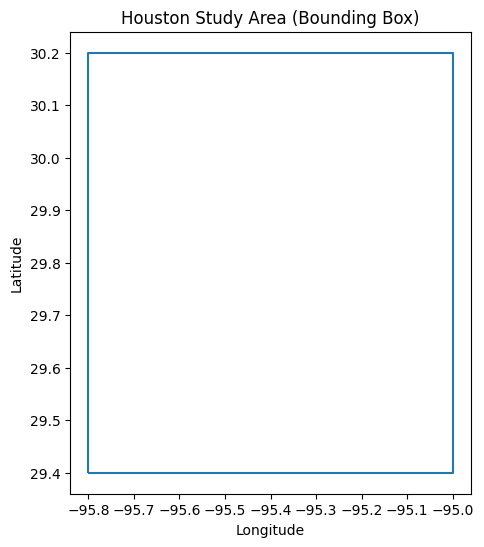

Saved figure to: /Users/suvo/Projects/flood-prediction/outputs/figures/00_study_area_bbox.png


In [3]:
fig, ax = plt.subplots(figsize=(6, 6))

study_area_gdf.boundary.plot(ax=ax)

ax.set_title("Houston Study Area (Bounding Box)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

save_figure(fig, FIG_GRID.parent / "00_study_area_bbox.png")

In [4]:
study_area_proj = study_area_gdf.to_crs(CRS_PROJECTED)

study_area_proj

,name,geometry
0,Houston,"POLYGON ((-10575351.625 3426656.25, -10575351...."


In [5]:
from shapely.geometry import box

minx, miny, maxx, maxy = study_area_proj.total_bounds
cell_size = GRID_SIZE_METERS

grid_cells = []
grid_ids = []

cell_id = 0
x = minx
while x < maxx:
    y = miny
    while y < maxy:
        cell = box(x, y, x + cell_size, y + cell_size)
        grid_cells.append(cell)
        grid_ids.append(cell_id)
        cell_id += 1
        y += cell_size
    x += cell_size

grid_gdf = gpd.GeoDataFrame(
    {"grid_id": grid_ids},
    geometry=grid_cells,
    crs=CRS_PROJECTED,
)

grid_gdf = gpd.overlay(grid_gdf, study_area_proj, how="intersection")
grid_gdf = grid_gdf[["grid_id", "geometry"]].copy()

print("Number of grid cells:", len(grid_gdf))
grid_gdf.head()

Number of grid cells: 378


,grid_id,geometry
0,0,"POLYGON ((-10659407.218 3431656.25, -10659407...."
1,1,"POLYGON ((-10659407.218 3436656.25, -10659407...."
2,2,"POLYGON ((-10659407.218 3441656.25, -10659407...."
3,3,"POLYGON ((-10659407.218 3446656.25, -10659407...."
4,4,"POLYGON ((-10659407.218 3451656.25, -10659407...."


In [6]:
grid_gdf = grid_gdf.to_crs(CRS_GEO)

grid_gdf.head()

,grid_id,geometry
0,0,"POLYGON ((-95.75508 29.43912, -95.75508 29.4, ..."
1,1,"POLYGON ((-95.75508 29.47823, -95.75508 29.439..."
2,2,"POLYGON ((-95.75508 29.51733, -95.75508 29.478..."
3,3,"POLYGON ((-95.75508 29.5564, -95.75508 29.5173..."
4,4,"POLYGON ((-95.75508 29.59547, -95.75508 29.556..."


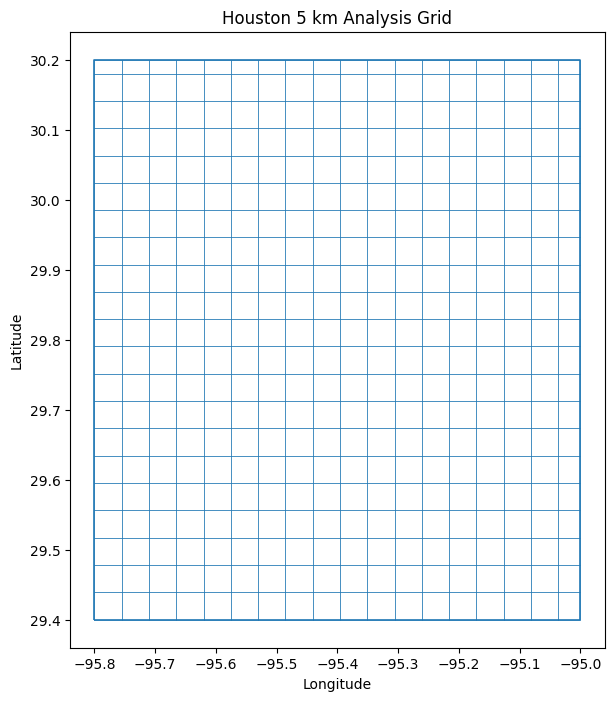

Saved figure to: /Users/suvo/Projects/flood-prediction/outputs/figures/01_houston_grid.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 8))

grid_gdf.boundary.plot(ax=ax, linewidth=0.4)
study_area_gdf.boundary.plot(ax=ax, linewidth=1.2)

ax.set_title("Houston 5 km Analysis Grid")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

save_figure(fig, FIG_GRID)

In [10]:
save_parquet(grid_gdf, GRID_FILE, index=False)

Saved parquet to: /Users/suvo/Projects/flood-prediction/data/interim/grids/houston_grid_1km.parquet


In [11]:
print("Number of grid cells:", len(grid_gdf))

minx, miny, maxx, maxy = grid_gdf.total_bounds
print("Bounds:", (minx, miny, maxx, maxy))

grid_gdf.head()

Number of grid cells: 378
Bounds: (np.float64(-95.8), np.float64(29.400000000000002), np.float64(-95.0), np.float64(30.2))


,grid_id,geometry
0,0,"POLYGON ((-95.75508 29.43912, -95.75508 29.4, ..."
1,1,"POLYGON ((-95.75508 29.47823, -95.75508 29.439..."
2,2,"POLYGON ((-95.75508 29.51733, -95.75508 29.478..."
3,3,"POLYGON ((-95.75508 29.5564, -95.75508 29.5173..."
4,4,"POLYGON ((-95.75508 29.59547, -95.75508 29.556..."


In [12]:
# Check approximate cell width/height in degrees
sample_geom = grid_gdf.geometry.iloc[0]
minx, miny, maxx, maxy = sample_geom.bounds

print("Cell size (deg):")
print("Longitude width:", maxx - minx)
print("Latitude height:", maxy - miny)

Cell size (deg):
Longitude width: 0.044915764205981645
Latitude height: 0.03912370253968689


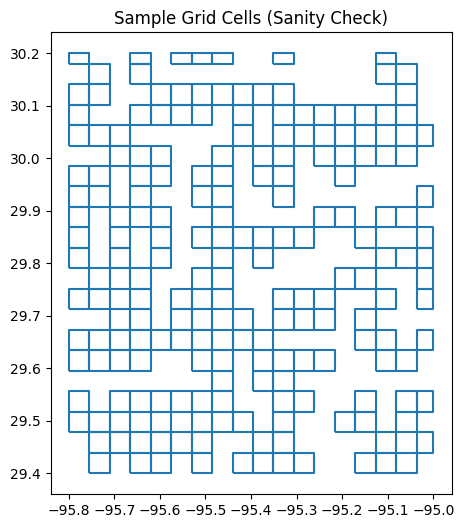

In [13]:
# Plot a small subset to visually inspect spacing
subset = grid_gdf.sample(200)

fig, ax = plt.subplots(figsize=(6, 6))
subset.boundary.plot(ax=ax)

ax.set_title("Sample Grid Cells (Sanity Check)")
plt.show()

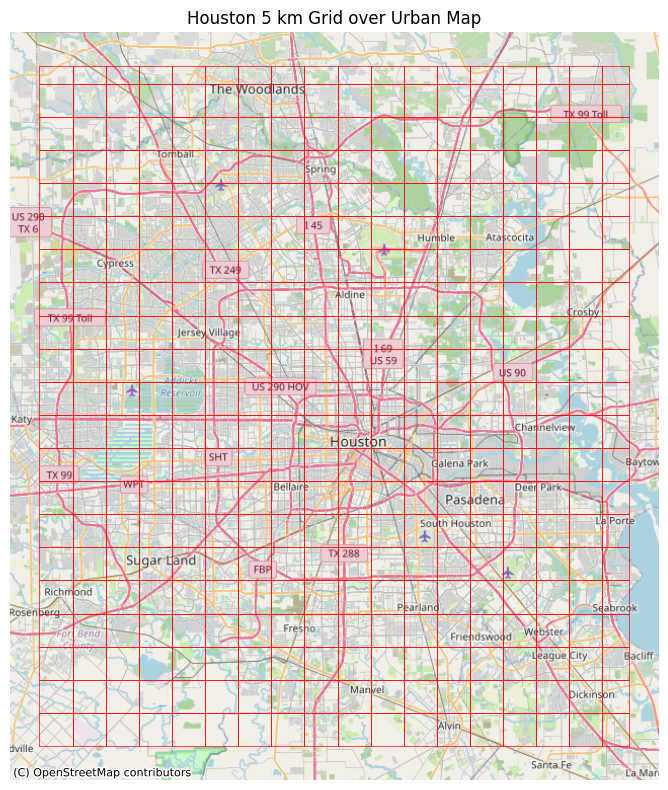

In [17]:
import contextily as ctx

# Project to Web Mercator for basemap
grid_plot = grid_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))

grid_plot.boundary.plot(ax=ax, linewidth=0.5, color="red")

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Houston 5 km Grid over Urban Map")
ax.set_axis_off()

plt.tight_layout()
fig.savefig("../outputs/figures/houston_grid_osm.png", dpi=300, bbox_inches="tight")
plt.show()